# Prediction specificity of different methods

In [160]:
from Bio.UniProt.GOA import GAF20FIELDS
from hogprop.OBOParser import OBO
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [60]:
def get_quickgo_annotation_count(t):
    url = "https://www.ebi.ac.uk/QuickGO/services/annotation/search"
    try:
        # only need term meta-data
        r = requests.get(url,
                         params={"goId": str(t), "limit": 1},
                         headers={"Accept": "application/json"})
        r.raise_for_status()
        return r.json().get("numberOfHits", 0)
        
    except requests.exceptions.RequestException as e:
        print(f"API Request failed: {e}")
        return -1

In [43]:
go = OBO('../data/geneontology/go.obo', store_as_int=True)

with open('../data/functional_predictions/unique_go_terms.txt', 'rt') as fp:
    all_terms = set(map(lambda x: go[x.rstrip()], fp.readlines()))

root_terms = {
    'P': 8150,
    'F': 3674,
    'C': 5575
}

root_counts = dict(map(lambda x: (x[0], get_quickgo_annotation_count(go[x[1]])), root_terms.items()))

In [61]:
root_counts

{'P': 260434638, 'F': 276350884, 'C': 197387903}

In [62]:
def gen(ts):
    i = 0
    for t in tqdm(ts):
        term_count = get_quickgo_annotation_count(t)
        term_freq = term_count / root_counts[t.aspect]
        term_ic = -np.log2(term_freq)
        yield {'go_id': str(t), 
               'depth': t.min_depth, 
               'quickgo_count': term_count,
               'quickgo_freq': term_freq,
               'quickgo_ic': term_ic}
        i += 1

In [161]:
go_term_stats_fn = '../data/functional_predictions/go_term_stats.tsv'

if os.path.isfile(go_term_stats_fn):
    df = pd.DataFrame(gen(all_terms))

    print('obsolete terms:', (df.quickgo_count == -1).sum())
    print('no annotation:', (df.quickgo_count == 0).sum())
    
    df = df[df.quickgo_count > 0]
    
    df.to_csv(go_term_stats_fn, sep='\t', index=False)
else:
    df = pd.read_csv(go_term_stats_fn)

NameError: name 'os' is not defined

In [162]:
df

,go_id,depth,quickgo_count,quickgo_freq,quickgo_ic
0,GO:0019884,3,6219,0.000024,15.353879
1,GO:0019899,3,1369599,0.004956,7.656604
2,GO:0019887,4,353503,0.001279,9.610563
3,GO:0019888,4,192980,0.000698,10.483834
4,GO:0019901,5,314826,0.001139,9.777731
...,...,...,...,...,...
21713,GO:0000256,4,23782,0.000091,13.418764
21714,GO:0070983,5,458,0.000002,19.117142
21715,GO:0000271,5,930105,0.003571,8.129312
21716,GO:0070987,7,20851,0.000080,13.608517


---

## Do some plots...

Count the number of proteins a go term is predicted using:

In [163]:
UNFILTERED_GAF_FN='../data/functional_predictions/all_predictions.gaf.gz'
UNFILTERED_COUNTS_FN='../data/functional_predictions/all_predictions_counts.tsv'
FILTERED_GAF_FN='../data/functional_predictions/all_predictions_filtered_viridiplantae.gaf.gz'
FILTERED_COUNTS_FN='../data/functional_predictions/all_predictions_counts_filtered_viridiplantae.tsv'

![[ -f {UNFILTERED_COUNTS_FN} ]] || zcat {UNFILTERED_GAF_FN} | cut -d $'\t' -f1,5 | sort | uniq -c > {UNFILTERED_COUNTS_FN}
![[ -f {FILTERED_COUNTS_FN} ]] || zcat {FILTERED_GAF_FN} | cut -d $'\t' -f1,5 | sort | uniq -c > {FILTERED_COUNTS_FN}

for now, manually remove the !gaf-version: 2.0 top line that appears here..

In [164]:
def read_counts_file(fn):
    def read():
        with open(fn, 'rt') as fp:
            for x in fp:
                x = x.strip()
                y = x.split(' ')
                count = int(y[0])
                z = y[1].split('\t')
                method = z[0]
                go_id = z[1]
                yield {'go_id': go_id, 'method': method, 'count': count}
                
    return pd.DataFrame(read())


unfiltered_counts = read_counts_file(UNFILTERED_COUNTS_FN)
filtered_counts = read_counts_file(FILTERED_COUNTS_FN)

In [165]:
def gen_long_form(counts_df):
    def gen():
        term_info = df.set_index('go_id').to_dict()
        all_terms_with_info = set(df.go_id)
        for (_, r) in counts_df.iterrows():
            if r.go_id in all_terms_with_info:
                x = {'go_id': r.go_id, 'method': r.method, 'depth': term_info['depth'][r.go_id], 'ic': term_info['quickgo_ic'][r.go_id]}
                for i in range(r['count']):
                     yield x
    return pd.DataFrame(gen())

In [166]:
unfiltered_counts_long_df = gen_long_form(unfiltered_counts)

In [167]:
filtered_counts_long_df = gen_long_form(filtered_counts)

In [168]:
unfiltered_counts_long_df

,go_id,method,depth,ic
0,GO:0000009,InterProScan,6,12.878630
1,GO:0000009,InterProScan,6,12.878630
2,GO:0000009,InterProScan,6,12.878630
3,GO:0000009,InterProScan,6,12.878630
4,GO:0000009,InterProScan,6,12.878630
...,...,...,...,...
66201020,GO:2001311,fantasia,5,17.829642
66201021,GO:2001311,fantasia,5,17.829642
66201022,GO:2001317,fantasia,5,25.634418
66201023,GO:2001317,fantasia,5,25.634418


In [169]:
filtered_counts_long_df

,go_id,method,depth,ic
0,GO:0000009,InterProScan,6,12.878630
1,GO:0000009,InterProScan,6,12.878630
2,GO:0000009,InterProScan,6,12.878630
3,GO:0000009,InterProScan,6,12.878630
4,GO:0000009,InterProScan,6,12.878630
...,...,...,...,...
63713306,GO:2001310,fantasia,5,23.708419
63713307,GO:2001310,fantasia,5,23.708419
63713308,GO:2001310,fantasia,5,23.708419
63713309,GO:2001310,fantasia,5,23.708419


In [175]:
for (method, zdf) in unfiltered_counts_long_df.groupby('method'):
    print(method, zdf.ic.mean())

InterProScan 7.631251138008546
eggnog-mapper 6.332829570520231
fantasia 11.344948231297835


In [176]:
for (method, zdf) in unfiltered_counts_long_df.groupby('method'):
    print(method, zdf.depth.mean())

InterProScan 3.9977455097111205
eggnog-mapper 3.2848342388855327
fantasia 4.2882828238856945


In [181]:
for (method, zdf) in unfiltered_counts_long_df.groupby('method'):
    print(method, len(set(zdf.go_id)))

InterProScan 4035
eggnog-mapper 10639
fantasia 19761


In [ ]:
### 1. plot boxplot of term depth per-method


### 2. plot boxplot of ic per-method

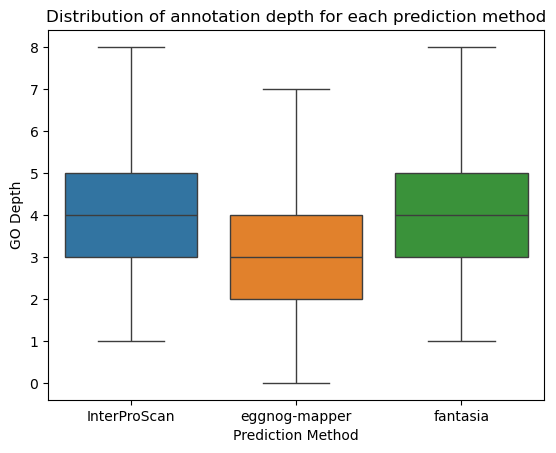

In [113]:
ax = sns.boxplot(data=filtered_counts_long_df, x='method', y='depth', hue='method', showfliers=False)
ax.set_title('Distribution of annotation depth for each prediction method')
ax.set_xlabel('Prediction Method')
ax.set_ylabel('GO Depth')
plt.savefig('../go_pred_filtered_depth.pdf', bbox_inches='tight')

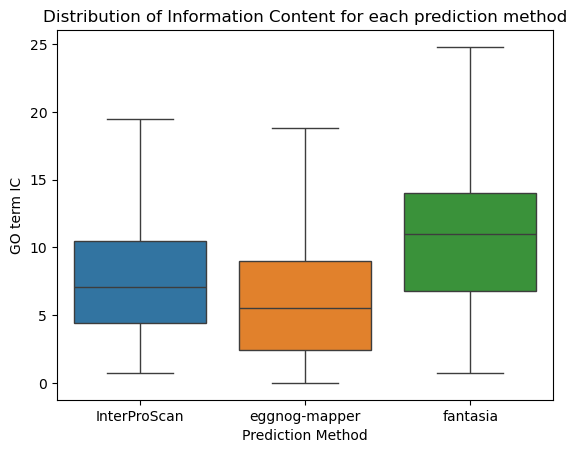

In [114]:
ax = sns.boxplot(data=filtered_counts_long_df, x='method', y='ic', hue='method', showfliers=False)
ax.set_title('Distribution of Information Content for each prediction method')
ax.set_xlabel('Prediction Method')
ax.set_ylabel('GO term IC')
plt.savefig('../go_pred_filtered_ic.pdf', bbox_inches='tight')

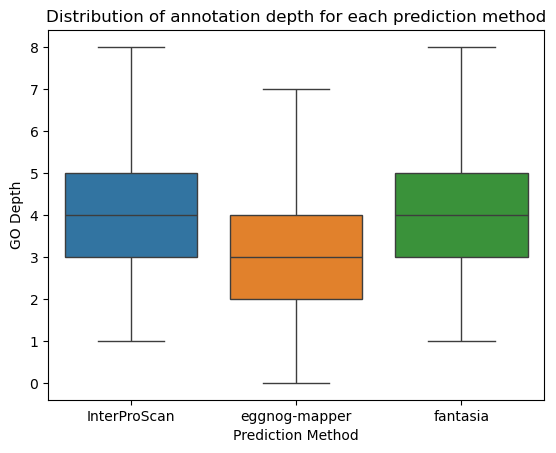

In [116]:
ax = sns.boxplot(data=unfiltered_counts_long_df, x='method', y='depth', hue='method', showfliers=False)
ax.set_title('Distribution of annotation depth for each prediction method')
ax.set_xlabel('Prediction Method')
ax.set_ylabel('GO Depth')
plt.savefig('../go_pred_unfiltered_depth.pdf', bbox_inches='tight')

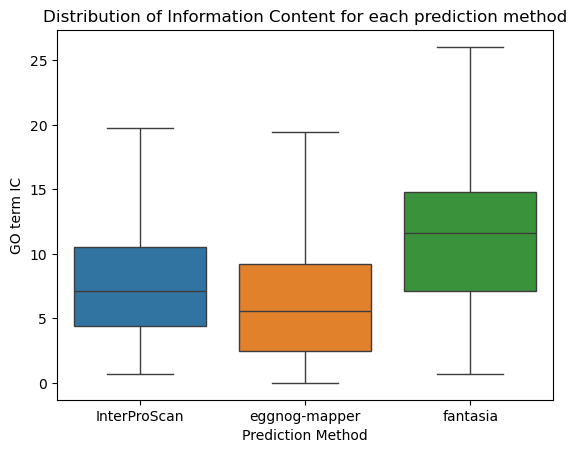

In [117]:
ax = sns.boxplot(data=unfiltered_counts_long_df, x='method', y='ic', hue='method', showfliers=False)
ax.set_title('Distribution of Information Content for each prediction method')
ax.set_xlabel('Prediction Method')
ax.set_ylabel('GO term IC')
plt.savefig('../go_pred_unfiltered_ic.pdf', bbox_inches='tight')

In [143]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn, posthoc_mannwhitney

In [144]:
def compute_stats(df, keys=['InterProScan', 'eggnog-mapper', 'fantasia']):
    ic = {}
    depth = {}
    for k in keys:
        zdf = df[df.method == k]
        ic[k] = zdf.ic.values
        depth[k] = zdf.depth.values

    print('ic kruskal', kruskal(*ic.values()))
    print('depth kruskal', kruskal(*depth.values()))

    print('ic dunn', posthoc_dunn(df, val_col='ic', group_col='method', p_adjust='fdr_bh'))
    print('depth dunn', posthoc_dunn(df, val_col='depth', group_col='method', p_adjust='fdr_bh'))

    print('ic mw', posthoc_mannwhitney(df, val_col='ic', group_col='method', p_adjust='fdr_bh'))
    print('depth mw', posthoc_mannwhitney(df, val_col='depth', group_col='method', p_adjust='fdr_bh'))

In [145]:
compute_stats(filtered_counts_long_df)

ic kruskal KruskalResult(statistic=8827993.01384397, pvalue=0.0)
depth kruskal KruskalResult(statistic=3849534.444803953, pvalue=0.0)
ic dunn                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
depth dunn                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
ic mw                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
depth mw                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0          

In [146]:
compute_stats(unfiltered_counts_long_df)

ic kruskal KruskalResult(statistic=10459859.3165972, pvalue=0.0)
depth kruskal KruskalResult(statistic=4262483.9988255575, pvalue=0.0)
ic dunn                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
depth dunn                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
ic mw                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0            0.0       1.0
depth mw                InterProScan  eggnog-mapper  fantasia
InterProScan            1.0            0.0       0.0
eggnog-mapper           0.0            1.0       0.0
fantasia                0.0         

In [158]:
f = filtered_counts_long_df.method == 'InterProScan'
filtered_counts_long_df[f].depth.mean()

3.9920322124013112

In [159]:
f = filtered_counts_long_df.method == 'fantasia'
filtered_counts_long_df[f].depth.mean()

4.2345258751532455

In [156]:
f = unfiltered_counts_long_df.method == 'InterProScan'
unfiltered_counts_long_df[f].depth.mean()

3.9977455097111205

In [157]:
f = unfiltered_counts_long_df.method == 'fantasia'
unfiltered_counts_long_df[f].depth.mean()

4.2882828238856945

In [ ]:
unfiltered_counts_long_df[unfiltered_counts_long_df == 'fantasia']['depth'].median()